# Fixed Income Portfolio Analytics: Carry, OCI Risk & Monte Carlo

This notebook builds three quantitative tools used in bank treasury and ALM (Asset & Liability Management) desks. Starting from a single bond and scaling to a simulated portfolio, it covers the core analytics a fixed income quant needs to manage both return and regulatory capital risk.

**Audience:** Quantitative practitioners with familiarity with bond pricing fundamentals, interest rate risk, and basic regulatory capital concepts (Basel III, IFRS 9).

**Portfolio used throughout:** Three UK Gilts — short (3yr), medium (5yr), and long (10yr) duration — chosen to illustrate how maturity and coupon affect each metric.

| Section | Tool | Question answered |
|---|---|---|
| 1 | Carry decomposition | Which bond earns the most net income after financing? |
| 2 | OCI scenario analysis | How much capital does a +100 bps shock consume? |
| 3 | Monte Carlo simulation | What is the probability of breaching the regulatory capital minimum? |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from FixedIncome.bonds import compute_dv01

## Section 1: Carry Decomposition

**What is carry?** Carry is the net P&L earned by holding a bond for one period, *assuming yields do not change*. It answers: if markets stay still, how much do I earn (or lose) holding this position?

**Why it matters in a portfolio context:** Carry is the baseline return before taking any view on rates. Portfolio managers use it to rank bonds on income efficiency and to verify that the financing cost of a position does not exceed its income. A negative-carry position requires a directional rate view to justify holding.

**The four components:**

| Component | Formula | Driver |
|---|---|---|
| Coupon income | `face × coupon_rate` | Contractual — fixed at issuance |
| Roll-down | `face × (roll_down_bps / 10000)` | Curve shape — steeper curve gives larger roll-down gain |
| Pull-to-par | `(face − price) / years` | Distance from par and time to maturity |
| Funding cost | `price × repo_rate` | Short-term financing rate (repo) |

**Net carry formula:** `Coupon income + Roll-down + Pull-to-par − Funding cost`

When carry is negative, the position is a net cost to hold — rate movement must compensate. This is why high-coupon, longer-dated bonds at a discount tend to carry best: coupon and pull-to-par both contribute positively.

In [3]:
# --- Bond definition ---
bond = {
    "name": "UK Gilt 4% 2029",
    "face_value": 100,
    "clean_price": 95,          # trading below par
    "coupon_rate": 0.04,        # 4% annual
    "years_to_maturity": 5,
    "repo_rate": 0.05,          # 5% annual funding cost
    "roll_down_bps": 15,        # yield pickup from rolling down curve
}

# --- Carry components (annualised, in £ per £100 face value) ---
coupon_income   =  bond["face_value"] * bond["coupon_rate"]
roll_down       =  bond["face_value"] * (bond["roll_down_bps"] / 10000)
pull_to_par     =  (bond["face_value"] - bond["clean_price"]) / bond["years_to_maturity"]
funding_cost    =  bond["clean_price"] * bond["repo_rate"]

total_carry = coupon_income + roll_down + pull_to_par - funding_cost

# --- Display ---
components = {
    "Coupon income":  coupon_income,
    "Roll-down":      roll_down,
    "Pull-to-par":    pull_to_par,
    "Funding cost":  -funding_cost,   # negative — it reduces carry
    "Total carry":    total_carry,
}

df = pd.DataFrame.from_dict(components, orient="index", columns=["£ per 100 face"])
print(df.round(2))

               £ per 100 face
Coupon income            4.00
Roll-down                0.15
Pull-to-par              1.00
Funding cost            -4.75
Total carry              0.40


The table above breaks out each carry component for the UK Gilt 4% 2029. Total carry of £0.40 per £100 face is small but positive: the coupon (£4.00) and pull-to-par (£1.00) nearly offset the funding cost (£4.75), with roll-down contributing only marginally (£0.15). This bond is close to breakeven on carry — a 25 bps rise in the repo rate would flip it negative. Holding it requires either a rate view (yields fall, price rises) or a strategic need for that duration exposure.

### Portfolio Carry Comparison

Comparing carry across multiple bonds reveals where the portfolio generates (or destroys) income. The bar chart below disaggregates each component so it is immediately clear whether total carry is driven by coupon, roll-down, or pull-to-par — and which bond is the drag.

                 Coupon income  Roll-down  Pull-to-par  Funding cost  \
Bond                                                                   
UK Gilt 4% 2029            4.0       0.15         1.00         -4.75   
UK Gilt 2% 2027            2.0       0.08         0.67         -4.90   
UK Gilt 5% 2035            5.0       0.20        -0.20         -5.10   

                 Total carry  
Bond                          
UK Gilt 4% 2029         0.40  
UK Gilt 2% 2027        -2.15  
UK Gilt 5% 2035        -0.10  


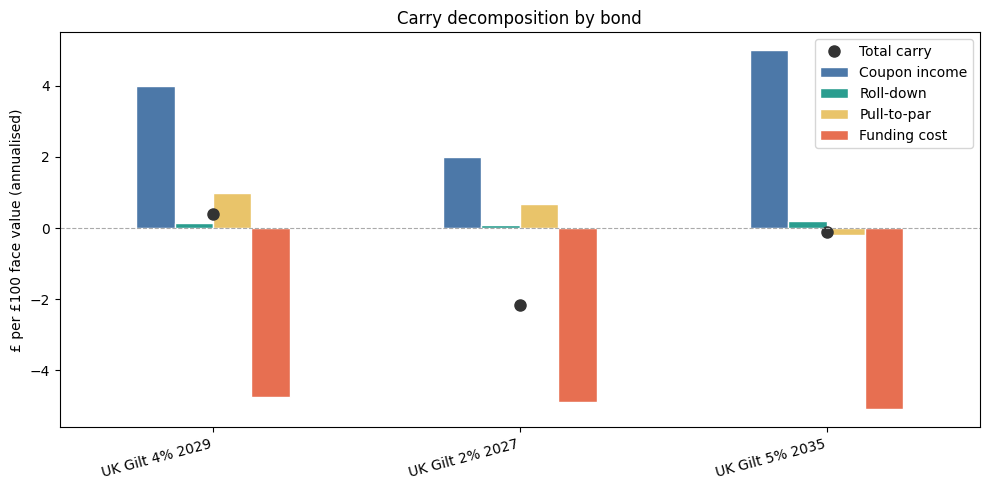

In [4]:

# --- Portfolio definition ---
portfolio = [
    {
        "name": "UK Gilt 4% 2029",
        "face_value": 100,
        "clean_price": 95,
        "coupon_rate": 0.04,
        "years_to_maturity": 5,
        "repo_rate": 0.05,
        "roll_down_bps": 15,
    },
    {
        "name": "UK Gilt 2% 2027",
        "face_value": 100,
        "clean_price": 98,
        "coupon_rate": 0.02,
        "years_to_maturity": 3,
        "repo_rate": 0.05,
        "roll_down_bps": 8,
    },
    {
        "name": "UK Gilt 5% 2035",
        "face_value": 100,
        "clean_price": 102,
        "coupon_rate": 0.05,
        "years_to_maturity": 10,
        "repo_rate": 0.05,
        "roll_down_bps": 20,
    },
]

# --- Compute carry components per bond ---
rows = []
for bond in portfolio:
    coupon_income = bond["face_value"] * bond["coupon_rate"]
    roll_down     = bond["face_value"] * (bond["roll_down_bps"] / 10000)
    pull_to_par   = (bond["face_value"] - bond["clean_price"]) / bond["years_to_maturity"]
    funding_cost  = bond["clean_price"] * bond["repo_rate"]
    total_carry   = coupon_income + roll_down + pull_to_par - funding_cost

    rows.append({
        "Bond":           bond["name"],
        "Coupon income":  coupon_income,
        "Roll-down":      roll_down,
        "Pull-to-par":    pull_to_par,
        "Funding cost":  -funding_cost,
        "Total carry":    total_carry,
    })

df = pd.DataFrame(rows).set_index("Bond")
print(df.round(2))

# --- Bar chart ---
components = ["Coupon income", "Roll-down", "Pull-to-par", "Funding cost"]
colors     = ["#4C78A8", "#2A9D8F", "#E9C46A", "#E76F51"]

ax = df[components].plot(
    kind="bar",
    figsize=(10, 5),
    color=colors,
    edgecolor="white",
)

# Overlay total carry as a dot
for i, val in enumerate(df["Total carry"]):
    ax.plot(i, val, "o", color="#333333", markersize=8, label="Total carry" if i == 0 else "")

ax.axhline(0, color="#AAAAAA", linewidth=0.8, linestyle="--")
ax.set_title("Carry decomposition by bond")
ax.set_ylabel("£ per £100 face value (annualised)")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the chart:** Each cluster of bars shows the four carry components for one bond. The black dot is total net carry — the number that matters for P&L.

Key observations:
- The long-dated **5% 2035** has the highest coupon income but also the highest funding cost (it trades above par at £102, raising the repo base). The large coupon is partly cancelled out
- The short **2% 2027** has low absolute carry and minimal roll-down — short-end bonds offer less roll benefit on a relatively flat curve segment
- The **4% 2029** balances moderate coupon with moderate funding cost, producing the most stable carry profile

**Pull-to-par note:** The 5% 2035 trades *above* par (£102), so pull-to-par is *negative* — as it approaches maturity it drifts down toward £100, dragging on carry. The two discount bonds (4% 2029 at £95, 2% 2027 at £98) both accrete upward, contributing positively.

**PM takeaway:** Rank bonds by carry *per unit of duration* (carry / DV01), not absolute carry. The 4% 2029 offers competitive income with intermediate duration — often a better risk-adjusted entry point than maximising coupon at the long end.

## Section 2: Interest Rate Risk — DV01 and Scenario Analysis

### 2a. DV01 (Dollar Value of a Basis Point)

**What is DV01?** DV01 measures how much a bond's price changes for a 1 basis point (0.01%) increase in yield. It is the foundational sensitivity measure in fixed income — used to size hedges, aggregate portfolio risk, and parameterise stress scenarios.

**Key formula:** `DV01 = P(y) − P(y + 0.0001)` (per £100 face value)

where `P(y)` is the bond price discounted at yield `y`. The result is the £ price change for a 1bp yield move, per £100 face.

**Intuition:**
- A 5yr bond has DV01 ≈ £0.043 — a 1bp yield move changes the price by ~4.3p per £100 face
- A 10yr bond has DV01 ≈ £0.079 — roughly twice the sensitivity, consistent with longer duration
- DV01 is a *linear approximation*: it assumes price moves proportionally with yield, ignoring convexity. For small yield moves this is accurate; for large shocks it understates gains and overstates losses

**Hedging application:** To construct a DV01-neutral hedge for £1m face of the 10yr gilt (DV01 ≈ £0.079 per £100 face), you would short a quantity of a shorter instrument such that the combined DV01 sums to zero.

In [5]:
# --- Portfolio with yields ---
portfolio = [
    {"name": "UK Gilt 4% 2029",  "face": 100, "coupon_rate": 0.04, "ytm": 0.045, "years": 5},
    {"name": "UK Gilt 2% 2027",  "face": 100, "coupon_rate": 0.02, "ytm": 0.035, "years": 3},
    {"name": "UK Gilt 5% 2035",  "face": 100, "coupon_rate": 0.05, "ytm": 0.048, "years": 10},
]

for bond in portfolio:
    bond["dv01"] = compute_dv01(
        bond["face"], bond["coupon_rate"], bond["ytm"], bond["years"]
    )
    print(f"{bond['name']:25s}  YTM: {bond['ytm']:.1%}  DV01: {bond['dv01']:.4f}")

UK Gilt 4% 2029            YTM: 4.5%  DV01: 0.0433
UK Gilt 2% 2027            YTM: 3.5%  DV01: 0.0272
UK Gilt 5% 2035            YTM: 4.8%  DV01: 0.0787


The DV01s confirm the duration relationship: the 10yr gilt (DV01 ≈ £0.079) is ~1.8× more rate-sensitive than the 5yr (£0.043) and ~2.9× the 3yr (£0.027). These values are the linear bridge between rate shocks and price changes — every calculation in Sections 2 and 3 depends on them. Note that the 10yr bond is only two years longer than the 5yr but carries significantly more DV01: duration grows non-linearly with maturity, especially for lower-coupon bonds.

### 2b. OCI Scenario Analysis — Regulatory Capital Impact of +100 bps

**What this scenario does:** Applies a deterministic parallel shift of +100 bps to all yields simultaneously — a standard regulatory stress test broadly equivalent to the EBA's IRRBB (Interest Rate Risk in the Banking Book) shock.

**Why CET1 matters:** Under IFRS 9, bonds classified as Available-for-Sale (AFS) are measured at fair value through Other Comprehensive Income (OCI). When rates rise and prices fall, the unrealised loss flows directly into equity — reducing the bank's CET1 ratio without touching the income statement.

**CET1 ratio:** `CET1 = Common Equity Tier 1 capital / Risk-Weighted Assets`

The Basel III minimum is 8% (Pillar 1) plus a 2.5% capital conservation buffer = **10.5% effective floor**. A bank that breaches this level faces restrictions on dividends and bonuses until the buffer is rebuilt.

**The transmission chain:**

`Rate shock (+100 bps)` → `Price change = −DV01 × 100` → `OCI loss = sum across AFS portfolio` → `Equity after = Equity − OCI loss` → `CET1 after = Equity after / RWA`

                   DV01  Price change
Bond                                 
UK Gilt 4% 2029  0.0433         -4.33
UK Gilt 2% 2027  0.0272         -2.72
UK Gilt 5% 2035  0.0787         -7.87

Shock applied:  +100 bps
OCI impact:     £-14.92 per £100 face value
CET1 before:    12.50%
CET1 after:     10.63%
CET1 change:    -1.86%


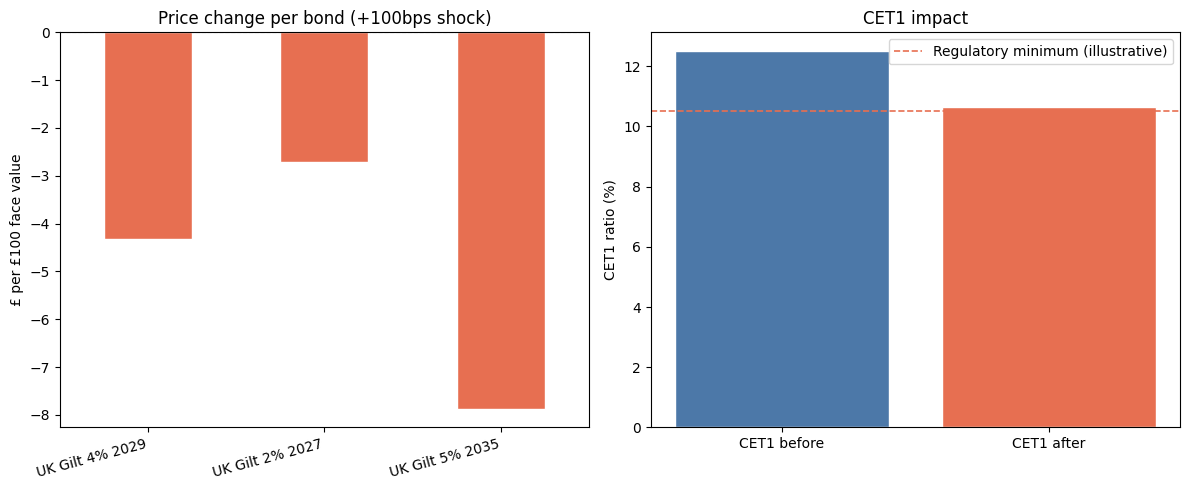

In [6]:
# --- Extend portfolio from Section 2a with AFS classification and market prices ---
# DV01s already computed via compute_dv01 above (per £100 face per 1bp)
for bond, clean_price in zip(portfolio, [95, 98, 102]):
    bond["clean_price"] = clean_price
    bond["classification"] = "AFS"

# --- Scenario definition ---
shock_bps = 100  # parallel rate shift upward

# --- CET1 parameters (scaled proportionate to £100 face portfolio) ---
total_equity = 100    # illustrative equity base
rwa          = 800    # illustrative RWA — gives 12.5% CET1 baseline
cet1_before  = total_equity / rwa

# --- Processing ---
rows = []
for bond in portfolio:
    # price_change per £100 face = −DV01 × shock_bps  (DV01 is £ per £100 face per 1bp)
    price_change = -bond["dv01"] * shock_bps
    rows.append({
        "Bond":         bond["name"],
        "DV01":         round(bond["dv01"], 4),
        "Price change": round(price_change, 2),
    })

df = pd.DataFrame(rows).set_index("Bond")

# OCI impact: aggregate unrealised loss across all AFS bonds
# Under IFRS 9, AFS (FVOCI) fair-value changes flow directly into equity via OCI — not the P&L
oci_impact = df["Price change"].sum()

# CET1 chain: equity is reduced by the OCI loss; RWA is unchanged in this model
equity_after = total_equity + oci_impact   # oci_impact is negative, so equity falls
cet1_after   = equity_after / rwa          # compare against 10.5% Basel III effective floor

print(df.round(4))
print(f"\nShock applied:  +{shock_bps} bps")
print(f"OCI impact:     £{oci_impact:.2f} per £100 face value")
print(f"CET1 before:    {cet1_before:.2%}")
print(f"CET1 after:     {cet1_after:.2%}")
print(f"CET1 change:    {(cet1_after - cet1_before):.2%}")

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: price change per bond
colors = ["#E76F51" if x < 0 else "#4C78A8" for x in df["Price change"]]
df["Price change"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].axhline(0, color="#AAAAAA", linewidth=0.8, linestyle="--")
axes[0].set_title(f"Price change per bond (+{shock_bps}bps shock)")
axes[0].set_ylabel("£ per £100 face value")
axes[0].set_xlabel("")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15, ha="right")

# Right: CET1 before vs after
axes[1].bar(["CET1 before", "CET1 after"],
            [cet1_before * 100, cet1_after * 100],
            color=["#4C78A8", "#E76F51"], edgecolor="white")
axes[1].set_title("CET1 impact")
axes[1].set_ylabel("CET1 ratio (%)")
axes[1].axhline(10.5, color="#E76F51", linewidth=1.2,
                linestyle="--", label="Regulatory minimum (illustrative)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the charts:**

*Left — price change per bond:* All bars are negative (rates up → prices down). The **5% 2035** (DV01 ≈ 0.079) takes the largest hit — roughly −£7.87 per £100 face on a +100 bps shock — confirming that long duration drives the majority of interest rate loss. The 3yr gilt is comparatively insulated.

*Right — CET1 before vs after:* The dashed red line marks the 10.5% regulatory floor. The gap between the "after" bar and that line is the remaining capital headroom. Whether the bar falls below the line determines whether the bank is in breach of its conservation buffer and faces distribution restrictions.

**Risk management conclusion:** The long-dated 5% 2035 is responsible for the bulk of CET1 erosion. A risk manager seeing this chart would look at adding an interest rate hedge on the long end — a receive-fixed swap or a gilt futures short — sized to reduce the portfolio DV01 and bring the post-shock CET1 comfortably above 10.5%.

An interactive version of this scenario tool — with adjustable rate shock, equity base, and RWA parameters — is available as a Streamlit app: `../Apps/oci_tool.py`.

## Section 3: Monte Carlo Rate Scenario Framework

**Why Monte Carlo over a single scenario?** The +100 bps scenario answers "what happens in one specific bad outcome". Monte Carlo answers: *across the full distribution of possible rate moves, what is the probability of a capital breach, and how severe can the tail get?*

**Methodology:**
1. Draw 1,000 rate shocks from `N(0, 50 bps)` — mean zero (no directional view), 50 bps standard deviation (calibrated to near-normal rate volatility)
2. Map each shock to a portfolio price change via DV01: `ΔP[i] = −shock[i] × DV01`
3. Sum across bonds to get total OCI per simulation
4. Derive a full CET1 distribution and read off tail statistics

**The `np.outer` operation** is the computational core. Rather than a loop over 1,000 simulations:
- `shocks` has shape `(1000,)` — one shock per simulation
- `dv01s` has shape `(3,)` — one DV01 per bond
- `np.outer(-shocks, dv01s)` produces shape `(1000, 3)` where each row is one complete simulation: all three bond price changes under that shock
- `.sum(axis=1)` collapses across bonds (columns) to give total portfolio OCI per simulation

**Key output statistics:** mean CET1, 5th-percentile CET1 (the stress-case capital level), and breach probability (fraction of simulations falling below 10.5%).

CET1 baseline:        12.50%
CET1 mean (sim):      12.48%
CET1 5th percentile:  10.94%
Prob breach 10.5%:    1.7%


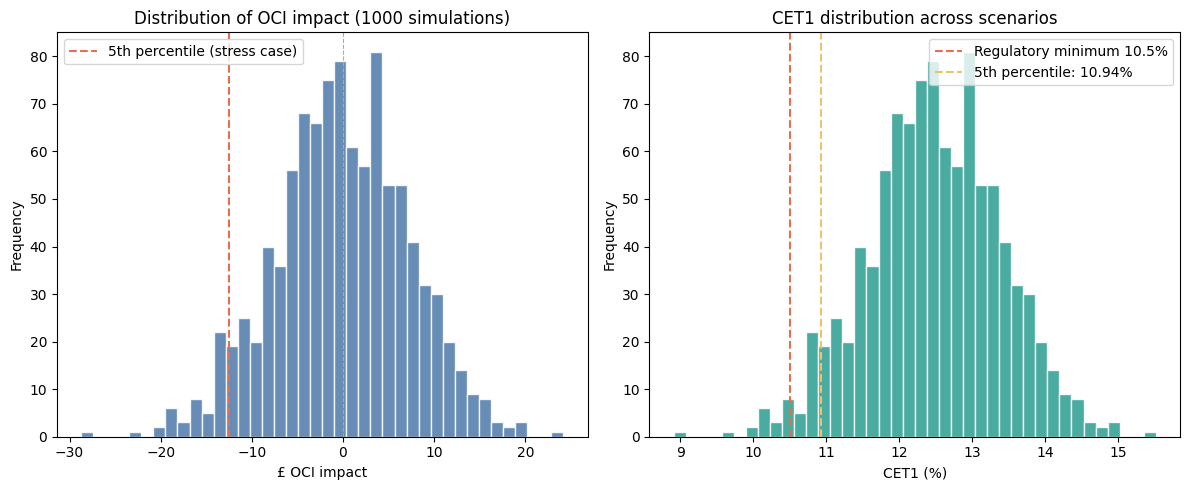

In [7]:

# --- Portfolio DV01s ---
dv01s = np.array([bond["dv01"] for bond in portfolio])  # shape: (3,)

# --- Simulation parameters ---
n_simulations = 1000
shock_mean    = 0       # bps — no directional view, centred on zero
shock_vol     = 50      # bps — one standard deviation, calibrated to near-normal rate conditions

# --- CET1 parameters (consistent with Section 2b) ---
total_equity = 100
rwa          = 800

# --- Stage 1: Draw random rate shocks ---
np.random.seed(42)
shocks = np.random.normal(shock_mean, shock_vol, n_simulations)  # shape: (1000,)

# --- Stage 2: Reprice portfolio under each scenario ---
# np.outer(-shocks, dv01s) is a vectorised outer product — no loop required:
#   shocks shape (1000,)  ×  dv01s shape (3,)  →  price_changes shape (1000, 3)
#   Row i:  [-shocks[i]*dv01[0],  -shocks[i]*dv01[1],  -shocks[i]*dv01[2]]
#   i.e., the price change for every bond under simulation i, computed simultaneously
price_changes = np.outer(-shocks, dv01s)

# Sum across bonds (axis=1 = collapse columns) to get total portfolio OCI per simulation
# Result shape: (1000,) — one aggregate OCI figure per simulation
oci_distribution = price_changes.sum(axis=1)

# --- Stage 3: CET1 distribution ---
# Equity shifts by OCI in every simulation; RWA is held constant
equity_distribution = total_equity + oci_distribution   # shape: (1000,)
cet1_distribution   = equity_distribution / rwa * 100   # convert to percentage

# --- Summary statistics ---
cet1_mean   = cet1_distribution.mean()
cet1_p5     = np.percentile(cet1_distribution, 5)   # 1-in-20 stress-case capital level
cet1_base   = total_equity / rwa * 100
breach_prob = (cet1_distribution < 10.5).mean() * 100  # fraction of simulations below regulatory floor

print(f"CET1 baseline:        {cet1_base:.2f}%")
print(f"CET1 mean (sim):      {cet1_mean:.2f}%")
print(f"CET1 5th percentile:  {cet1_p5:.2f}%")
print(f"Prob breach 10.5%:    {breach_prob:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: OCI distribution
axes[0].hist(oci_distribution, bins=40, color="#4C78A8",
             edgecolor="white", alpha=0.85)
axes[0].axvline(np.percentile(oci_distribution, 5), color="#E76F51",
                linestyle="--", label="5th percentile (stress case)")
axes[0].axvline(0, color="#AAAAAA", linewidth=0.8, linestyle="--")
axes[0].set_title("Distribution of OCI impact (1000 simulations)")
axes[0].set_xlabel("£ OCI impact")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Right: CET1 distribution
axes[1].hist(cet1_distribution, bins=40, color="#2A9D8F",
             edgecolor="white", alpha=0.85)
axes[1].axvline(10.5, color="#E76F51", linestyle="--",
                label="Regulatory minimum 10.5%")
axes[1].axvline(cet1_p5, color="#E9C46A", linestyle="--",
                label=f"5th percentile: {cet1_p5:.2f}%")
axes[1].set_title("CET1 distribution across scenarios")
axes[1].set_xlabel("CET1 (%)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the histograms:**

*Left — OCI distribution:* The distribution is centred near zero (rate shocks are mean-zero), but the left tail extends to large losses. The red dashed line marks the 5th percentile — in roughly 1 in 20 simulations, the OCI loss is worse than this level. This is the portfolio's 95% VaR expressed in OCI terms.

*Right — CET1 distribution:* The key comparison is between the orange dashed line (5th-percentile CET1) and the red dashed line (10.5% regulatory floor):
- If the 5th-percentile line is *above* 10.5%, the portfolio survives all but extreme tail scenarios under the assumed volatility
- If it is *below* 10.5%, there is a measurable probability of a capital breach even under "normal" rate conditions — a signal to add hedges or hold more capital buffer

**Actions a risk manager takes from this output:**
1. Set the internal capital buffer target to sit above the 5th-percentile shortfall
2. Size an interest rate hedge to shift the distribution rightward (higher CET1 at all percentiles)
3. Re-run with higher `shock_vol` (e.g. 100 bps) to stress-test under crisis conditions

## Summary: From Carry to Capital Risk

This notebook builds three tools that chain together in a real treasury workflow:

**1. Carry decomposition** establishes the baseline: which bonds generate net income after financing costs, and how much. Carry analysis informs position sizing *before* introducing rate risk — there is no point holding a negative-carry bond unless it provides a valuable hedge or there is a strong rate view to support it.

**2. OCI scenario analysis** translates a specific rate shock into a regulatory capital impact. It answers the deterministic question: can the portfolio survive a +100 bps move without breaching the Basel III 10.5% CET1 floor? This is the tool a risk manager runs before every ALCO (Asset & Liability Committee) meeting.

**3. Monte Carlo simulation** replaces the single scenario with a full distribution. It quantifies tail risk — the 5th-percentile CET1, the breach probability, and the expected shortfall — providing a probabilistic basis for hedging decisions and capital buffer sizing.

**The workflow in practice:**
- Use **carry** to select which bonds to hold and assess income efficiency
- Use **DV01** to measure and aggregate rate sensitivity across the portfolio
- Use **OCI scenario** to check regulatory capital compliance under a defined stress shock
- Use **Monte Carlo** to size the capital buffer and justify hedge ratios to senior management

Together, these three tools cover the core quantitative toolkit at a bank treasury or CIO desk.